In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats as ss

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/')

In [21]:
df = pd.read_csv('DB-TESIS.csv')

In [22]:
#df.head()

In [23]:
#Para vizualizar toda la data
%config Completer.use_jedi = False
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#1. Validacion de Datos

In [24]:
#Qué tipo de datos son las variables del conjunto de datos?
#df.dtypes

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Columns: 234 entries, ID to 424_RESULTADO_GLUCOSA
dtypes: float64(154), int64(68), object(12)
memory usage: 1.9+ MB


In [26]:
#¿Cuantas variables de cada tipo de dato tenemos en el conjunto de datos?
df.dtypes.value_counts()

,count
float64,154
int64,68
object,12


In [27]:
#¿Cuantas observaciones y variables tenemos en el conjunto de datos?
df.shape

(1079, 234)

In [28]:
#¿Existen valores nulos explícitos en el conjunto de datos?
#df.isnull().any()

In [29]:
#¿De tener observaciones con valores nulos? ¿Cuántas tenemos por cada variable?
#df.isnull().sum()

In [30]:
#¿Cuantos valores nulos tenemos en el total en el conjunto de datos?
df.isnull().sum().sum()

np.int64(17044)

In [31]:
#¿Cuantos valores ceros tenemos en el total en el conjunto de datos?
total_ceros = (df == 0).sum().sum()
total_ceros

np.int64(95692)

In [32]:
#¿Cuantas observaciones perdemos si eliminamos los datos faltantes?
df.shape,df.dropna().shape

((1079, 234), (0, 234))

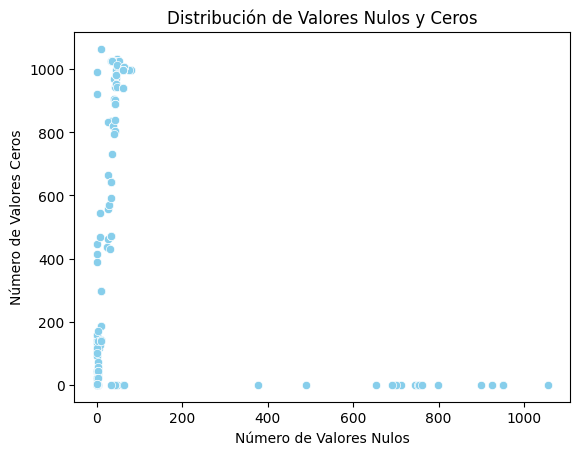

In [33]:


# Concatena las columnas con valores nulos y ceros
valores_faltantes = pd.concat([df.isnull().sum(), (df == 0).sum()], axis=1)
valores_faltantes.columns = ['Nulos', 'Ceros']

# Crea un diagrama de puntos
sns.scatterplot(data=valores_faltantes, x='Nulos', y='Ceros', color='skyblue')
plt.xlabel('Número de Valores Nulos')
plt.ylabel('Número de Valores Ceros')
plt.title('Distribución de Valores Nulos y Ceros')
plt.show()

In [34]:

# Calcula el porcentaje de NaN en cada columna
porcentaje_nan = df.isnull().mean()

# Filtra las columnas que tienen más del 80% de NaN
columnas_a_eliminar = porcentaje_nan[porcentaje_nan > 0.2].index

# Elimina las columnas seleccionadas
df_sin_columnas_nan = df.drop(columns=columnas_a_eliminar)

# Imprime el DataFrame resultante
df_sin_columnas_nan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Columns: 218 entries, ID to 424_RESULTADO_GLUCOSA
dtypes: float64(138), int64(68), object(12)
memory usage: 1.8+ MB


In [35]:
# Calcula el porcentaje de ceros en cada columna
porcentaje_ceros = (df_sin_columnas_nan == 0).mean()

# Filtra las columnas que tienen más del 80% de ceros
columnas_a_eliminar_ceros = porcentaje_ceros[porcentaje_ceros >= 0.2].index

# Elimina las columnas seleccionadas
df_final = df_sin_columnas_nan.drop(columns=columnas_a_eliminar_ceros)

# Imprime el DataFrame resultante
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Columns: 112 entries, ID to 424_RESULTADO_GLUCOSA
dtypes: float64(37), int64(63), object(12)
memory usage: 944.3+ KB


In [36]:
#analizamos si las variables object son relevantes
#df_sin_columnas_nan.dtypes.isnull().sum().sum()

In [37]:
# Identificar características tipo 'object'
object_features = df_final.select_dtypes(include=['object'])

# Calcular el porcentaje de valores 0 para cada característica
zero_percentage = (object_features == "0").mean()

# Filtrar características que tienen más del 80% de valores 0
features_to_drop = zero_percentage[zero_percentage > 0.8].index

# Eliminar estas características del DataFrame
df_final = df_final.drop(features_to_drop, axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Columns: 105 entries, ID to 424_RESULTADO_GLUCOSA
dtypes: float64(37), int64(63), object(5)
memory usage: 885.2+ KB


In [38]:
c_ob = df_final.select_dtypes(include=['object'])
c_ob

,PERFIL LIPIDICO,409_DESCRIPCION_PRENDA1,409_DESCRIPCION_PRENDA2,409_DESCRIPCION_PRENDA3,409_DESCRIPCION_PRENDA4
0,SI,POLO ALGODÓN M/C TALLA M,BUZO PANTALON DE ALGODÓN TALLA M,TRUZA DE ALGODÓN TALLA M,0
1,SI,POLO ALGODÓN M/L TALLA L,BUZO PANTALON DE ALGODÓN TALLA L,POLO ALGODÓN BVD TALLA L,TRUZA DE ALGODÓN TALLA L
2,SI,POLO ALGODÓN M/C TALLA S,PANTALON LARGO DE JEAN 15-50 AÑOS,TRUZA DE ALGODÓN TALLA S,POLO ALGODÓN BVD TALLA S
3,SI,POLO SINTÉTICO M/L TALLA 8,CALZON DE ALGODÓN TALLA L,POLO ALGODÓN BVD TALLA XL,BRASIER CORTO 15-50 AÑOS
4,SI,PANTALON JEAN TALLA 28,POLO DE ALGODON M/C TALLA M,TRUZA DE ALGODÓN TALLA M,NaN
5,SI,POLO ALGODON M/C TALLA S,FALDA DE ALGODON TALLA S,CALZON DE ALGODÓN TALLA S,0
6,SI,BLUSA DE TELA M/C TALLA M,PANTALON TELA TALLA M,CALZON DE ALGODÓN TALLA M,0
7,SI,SHORT SINTETICO TALLA S,POLO DE ALGODON M/C TALLA S,TRUZA DE ALGODÓN TALLA S,0
8,SI,SHORT JEAN TALLA L,POLO DE ALGODON M/C TALLA M,TRUZA DE ALGODÓN TALLA L,0
9,SI,POLO SINTETICO M/C TALLA M,PANTALONETA DE ALGODON TALLA M,CALZON DE ALGODÓN TALLA M,BRASIER CORTO 15-50 AÑOS


In [39]:
#Tras hacer el analisis las columnas "objec" no son relevantes


# Seleccionar todas las columnas de tipo objeto
columnas_objeto = df_final.select_dtypes(include='object').columns

# Eliminar las columnas de tipo objeto del DataFrame
df_sin_objetos = df_final.drop(columns=columnas_objeto)

#eliminando lso identificadores unicos
df_ultimate = df_sin_objetos.drop(columns=['ID','Conglomerado','Vivienda','HOGAR','ID_ADULTO','HORA_INICIO','MIN_INICIO','HORA_FINAL','MIN_FINAL','409_CODIGO1','409_CODIGO2','409_CODIGO3'])

df_ultimate.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 88 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DIA                                            1079 non-null   int64  
 1   MES                                            1079 non-null   int64  
 2   701_ACTIVIDAD_FISICA_VIGOROSA_DIAS             1079 non-null   int64  
 3   703_ACTIVIDAD_FISICA_MODERADA_DIAS             1079 non-null   int64  
 4   705_CAMINAR_DIAS                               1079 non-null   int64  
 5   708_FUMA_ACTUALMENTE                           1079 non-null   int64  
 6   713_PASADO_FUMO_DIARIO                         1077 non-null   float64
 7   718.1_PELIGROS_FUMAR_DIARIOS                   1079 non-null   int64  
 8   718.2_PELIGROS_FUMAR_TELEVISION                1079 non-null   int64  
 9   718.3_PELIGROS_FUMAR_RADIO                     1079 

In [40]:
columnas_de_interes = ['410_TALLA_ENTERO', '408_PESO_NETO_ENTERO', '408_PESO_NETO_DECIMAL', '420_RESULTADO_HEMOGLOBINA_ENTERO', '420_RESULTADO_HEMOGLOBINA_DECIMAL']

# Obtener la descripción de las tres columnas
descripcion_columnas = df_sin_objetos[columnas_de_interes].describe()
descripcion_columnas

,410_TALLA_ENTERO,408_PESO_NETO_ENTERO,408_PESO_NETO_DECIMAL,420_RESULTADO_HEMOGLOBINA_ENTERO,420_RESULTADO_HEMOGLOBINA_DECIMAL
count,1079.000000,1079.000000,1079.000000,1077.000000,1077.000000
mean,156.754402,66.831325,4.427247,13.313835,4.374188
std,12.170630,14.205532,2.804720,2.740974,2.943742
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,150.000000,57.000000,2.000000,12.000000,2.000000
50%,156.000000,65.000000,4.000000,13.000000,4.000000
75%,164.000000,74.000000,7.000000,15.000000,7.000000
max,186.000000,128.000000,9.000000,21.000000,9.000000


In [41]:

# Añadiendo nueva columna PESO_FINAL
columna1 = df_ultimate['408_PESO_NETO_ENTERO']
columna2 = df_ultimate['408_PESO_NETO_DECIMAL']/10

df_ultimate['PESO_FINAL'] = columna1 + columna2

# Añadiendo una nueva columna 'IMC' al DataFrame
df_ultimate['IMC'] = df_ultimate['PESO_FINAL'] / ((df_ultimate['410_TALLA_ENTERO'] / 100) ** 2)

#Añadiendo una nueva columna 'EMOGLOBINA_FINAL'
columna1 = df_ultimate['420_RESULTADO_HEMOGLOBINA_ENTERO']
columna2 = df_ultimate['420_RESULTADO_HEMOGLOBINA_DECIMAL']/10
df_ultimate['EMOGLOBINA_FINAL'] = columna1 + columna2
df_ultimate= df_ultimate.drop(columns=['420_RESULTADO_HEMOGLOBINA_ENTERO','420_RESULTADO_HEMOGLOBINA_DECIMAL','408_PESO_NETO_ENTERO','408_PESO_NETO_DECIMAL'])
# Mostrar el DataFrame con las nuevas columna
#nuevas_columnas = ['PESO_FINAL', 'IMC','EMOGLOBINA_FINAL']
#df_ultimate[nuevas_columnas].describe()



#2. Importancia de las Características:

In [42]:
#¿Cuantas observaciones perdemos si eliminamos los datos faltantes?
df_ultimate.shape,df_ultimate.dropna().shape

((1079, 87), (1053, 87))

In [43]:
df_sin_nan = df_ultimate.dropna()

In [44]:
df_sin_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1053 entries, 0 to 1078
Data columns (total 87 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DIA                                            1053 non-null   int64  
 1   MES                                            1053 non-null   int64  
 2   701_ACTIVIDAD_FISICA_VIGOROSA_DIAS             1053 non-null   int64  
 3   703_ACTIVIDAD_FISICA_MODERADA_DIAS             1053 non-null   int64  
 4   705_CAMINAR_DIAS                               1053 non-null   int64  
 5   708_FUMA_ACTUALMENTE                           1053 non-null   int64  
 6   713_PASADO_FUMO_DIARIO                         1053 non-null   float64
 7   718.1_PELIGROS_FUMAR_DIARIOS                   1053 non-null   int64  
 8   718.2_PELIGROS_FUMAR_TELEVISION                1053 non-null   int64  
 9   718.3_PELIGROS_FUMAR_RADIO                     1053 non-n

#3. Selección de Características:

In [45]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Suponiendo que df_sin_nan es tu DataFrame original
X = df_sin_nan.drop('IMC', axis=1)
y = df_sin_nan['IMC']

# Normalizar las características de entrada
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Crear el estimador SVR con kernel lineal
estimator = SVR(kernel="linear")

# Crear el selector de características RFE
selector = RFE(estimator, n_features_to_select=20, step=1)

# Ajustar el selector a los datos de entrada normalizados
selector = selector.fit(X_normalized, y)

# Obtén las características seleccionadas
selected_features = selector.support_

# Filtra las características seleccionadas en el DataFrame original
selected_X = X.loc[:, selected_features]

# Combina las características seleccionadas con la variable objetivo
selected_df = pd.concat([selected_X, y], axis=1)


In [46]:
import pandas as pd

# total de datos
total_datos = selected_df.shape[0] * df.shape[1]
print("El total de datos en el DataFrame es:", total_datos)

El total de datos en el DataFrame es: 246402


In [47]:
total_ceros_1 = (selected_df == 0).sum().sum()
total_ceros_1

np.int64(813)

In [48]:
#Creamos un DF  omitiendo las filas que contiene valores = 0
#df_sin_ceros = selected_df[(selected_df != 0).all(axis=1)]

In [49]:
# Imputar valores cero con la media de la columna
df_limpio = selected_df.replace(0, selected_df.mean())

In [50]:
#¿Cuantos valores ceros tenemos en el total en el conjunto de datos?
total_ceros = (df_limpio == 0).sum().sum()
total_ceros

np.int64(0)

In [51]:
#¿Cuantos valores nulos tenemos en el total en el conjunto de datos?
df_limpio.isnull().sum().sum()

np.int64(0)

In [52]:
#si tuviese NaN pasamos a eliminar esa filas
#df_sin_nan = df_sin_ceros.dropna()

In [53]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1053 entries, 0 to 1078
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   COLESTEROL (mg/dL)                 1053 non-null   float64
 1   LDL COLESTEROL (mg/dL)             1053 non-null   float64
 2   407_PESO_BRUTO_ENTERO              1053 non-null   int64  
 3   407_PESO_BRUTO_DECIMAL             1053 non-null   float64
 4   409_PESO_PRENDA1                   1053 non-null   int64  
 5   409_PESO_PRENDA2                   1053 non-null   int64  
 6   409_PESO_PRENDA3                   1053 non-null   float64
 7   410_TALLA_ENTERO                   1053 non-null   int64  
 8   413_PERIMETRO_ENTERO               1053 non-null   float64
 9   414_PRESION_ARTERIAL_AÑO           1053 non-null   float64
 10  415_PRIMERA_MEDIDA_DIASTOLICA      1053 non-null   float64
 11  416_SEGUNDA_MEDIDA_ DIASTOLICA     1053 non-null   float64
 1

In [54]:
# Crear un diccionario de mapeo de nombres de columna
nombre_columnas = {
    'COLESTEROL (mg/dL)': 'COL',
    'LDL COLESTEROL (mg/dL)': 'LDL',
    '407_PESO_BRUTO_ENTERO': 'GWW',
    '407_PESO_BRUTO_DECIMAL': 'GDW',
    '409_PESO_PRENDA1': 'WP1',
    '409_PESO_PRENDA2': 'WP2',
    '409_PESO_PRENDA3': 'WP3',
    '410_TALLA_ENTERO': 'SIZE',
    '413_PERIMETRO_ENTERO': 'PE',
    '414_PRESION_ARTERIAL_AÑO': 'PAY',
    '415_PRIMERA_MEDIDA_DIASTOLICA': 'FDM',
    '416_SEGUNDA_MEDIDA_ DIASTOLICA': 'SDM',
    '418_RESULTADO_FINAL_DIASTOLICA': 'DFR',
    '419_HEMOGLOBINA_AÑO': 'Hb_Y',
    '422_SANGRE_VENOSA_AÑO': 'VBY',
    '424_RESULTADO_PERIMETRO_ABDOMINAL': 'APR',
    '424_RESULTADO_HB': 'Hb',
    '424_RESULTADO_PRESION_ARTERIAL': 'RAP',
    '424_RESULTADO_GLUCOSA': 'Glc',
    'PESO_FINAL': 'FW'
}

# Renombrar las columnas
df_limpio.rename(columns=nombre_columnas, inplace=True)

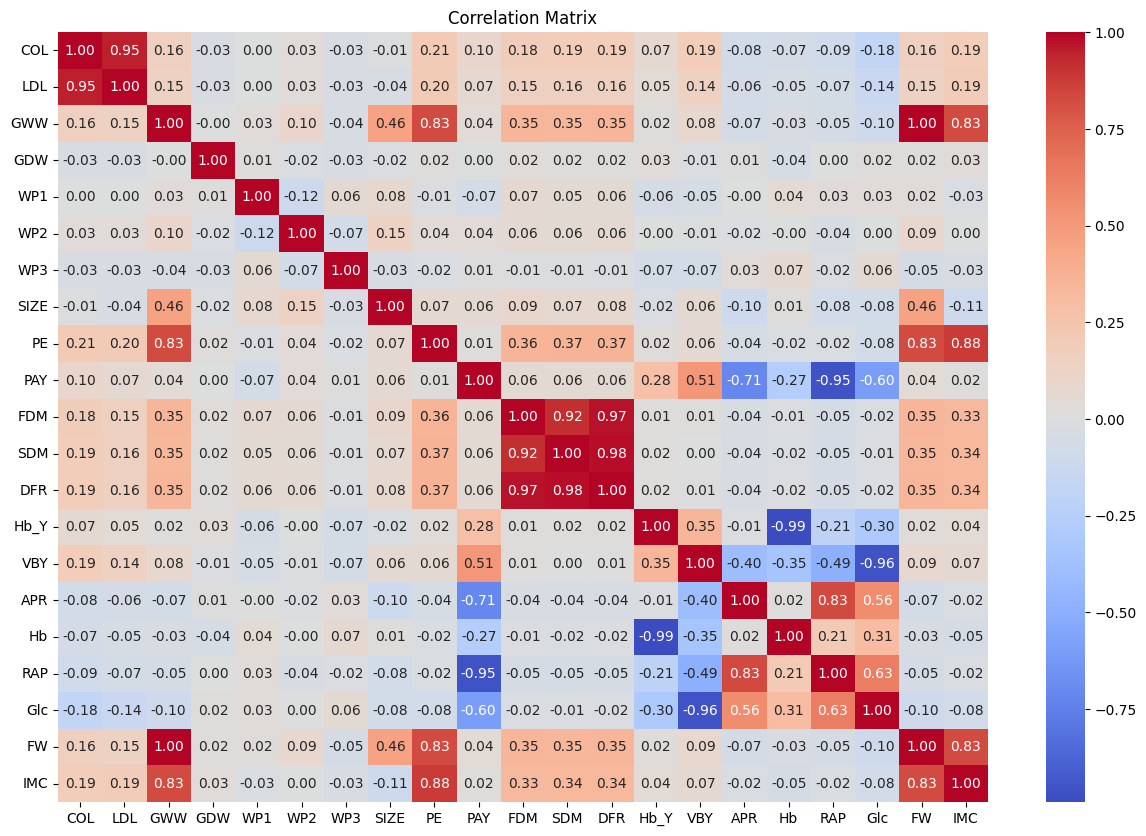

In [55]:
#Matriz de Correlación
plt.figure(figsize=(15, 10))
sns.heatmap(df_limpio.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [56]:
df_limpio.to_csv('/content/drive/My Drive/Colab Notebooks/Data_Limpia.csv', index=False)